# Project: Wrangling and Analyze Data

## Table of content 
- 1.1 [Gathering ](#gather)
- 1.1.2 [twitter archive](#gather1)
- 1.1.3 [Image prediction](#gather2)
- 1.1.4 [twitter api](#gather3)
- 2.1. [Assessing Data](#assess)
- 2.1.1 [Assessing twitter_archive](#assess1)
- 2.2.2 [Quality issues with twitter archive/ df_archive](#assess2)
- 2.2.3 [Tidiness issues tweet_archive](#assess3)

- 2.3.1 [Assessing Image Prediction( image_pred)](#assess4)
- 2.3.2 [Quality issue](#assess5)
- 2.3.3 [Tidiness issue](#assess6)
- 2.4.1 [Assessing tweets_df](#assess7)
- 2.4.2 [Quality Issue with tweets_df](#assess8)
- 2.2.3 [Tidyness issue](#assess9)
- 3.1 [Cleaning Data](#clean1)
- 3.2 [Issue 1: changing time stamp from oject to datetime](#clean2)
- 3.3 [Issue 2 and 3: dropping null values](#clean3)
- 3.4 [Issue 4 and 5: drooping null values](#clean4)
- 3.5 [Issue 6: Dropping irrelevant columns](#clean5)
- 3.6 [Issue 7: source contains anchor tags, re-extracting source](#clean6)
- 3.7 [Issue 8: Extracting properly numerator and denominator in ratings](#clean7)
- 3.8 [Issue 9: making dog stages into one column](#clean8)
- 3.9 [Issue 10: removing tweets that contains no dog.](#clean9)
- 3.10 [Isuue 11: renaming column name id to tweet_id in tweets](#clean10)
- 3.11 [Issue 12: selecting images that are only dogs](#clean11)
- 3.12 [Issue 13: Dropping irrelevant column in image prediction](#clean12)
- 3.13 [Issue 14: changing rating_numerator and denominator to float](#clean13)
- 3.14 [Issue 15: merging dataframe into one dataframe](#clean14)
- 3.15 [Saving master dataframe as twitter_archive_master.csv](#save1)
- 3.16 [Checking for outliers](#out1)
- 3.17 [checking for outliers in rating_numerator](#out2)
- 4.1 [Analyzing and Visualizing Data](#ana1)
- 4.1.1 [Question 1](#que1)
- 4.1.2 [Question 2](#que2)
- 4.1.3 [Question 3](#que3)
- 5.1 [Insigths](#ins1)
- 6.1 [Visualization](#vis1)
- 7.1 [Refrences](#res1)

##  <a id=gather> Data Gathering </a>
In the cell below, gather **all** three pieces of data for this project and load them in the notebook. **Note:** the methods required to gather each data are different.
1. Directly download the WeRateDogs Twitter archive data (twitter_archive_enhanced.csv)

In [131]:
#importing libraries for analysis
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import requests
import json
import numpy as np

%matplotlib inline

<a id=gather1> reading twitter archive </a>

In [132]:
df_archive = pd.read_csv('twitter-archive-enhanced.csv')   #reading in twitter-archive-enchanced

In [133]:
df_archive.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None


<a id=gather2> 2. Use the Requests library to download the tweet image prediction (image_predictions.tsv)</a>

In [134]:
# querring the url
url = 'https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv'

response = requests.get(url)

In [135]:
response #checking if response is good

<Response [200]>

In [136]:
#creating image_prediction as tsv file and reading response with a context manager as file
with open('image_prediction.tsv', 'wb') as file:  
    file.write(response.content)

In [137]:
image_pred = pd.read_csv('image_prediction.tsv', sep='\t') #loading image_prediction into dataframe

In [138]:
image_pred.head() #checking if it is properly read

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


<a id=gather3>3. Use the Tweepy library to query additional data via the Twitter API (tweet_json.txt)</a>

In [139]:
#reading tweet html with a context manager line by line 
tweets_list = []

with open('tweet-json.txt', 'r') as file:
    for line in file:
        data = json.loads(line)
        tweets_list.append(data)   

In [140]:
#reading tweets into pandas
tweets_df = pd.DataFrame(tweets_list, columns=['id', 'retweet_count', 'favorite_count'])

In [141]:
#checking if it is read
tweets_df.head() 

,id,retweet_count,favorite_count
0,892420643555336193,8853,39467
1,892177421306343426,6514,33819
2,891815181378084864,4328,25461
3,891689557279858688,8964,42908
4,891327558926688256,9774,41048


## <a id = assess> Assessing Data </a>
In this section, detect and document at least **eight (8) quality issues and two (2) tidiness issue**. You must use **both** visual assessment
programmatic assessement to assess the data.

**Note:** pay attention to the following key points when you access the data.

* You only want original ratings (no retweets) that have images. Though there are 5000+ tweets in the dataset, not all are dog ratings and some are retweets.
* Assessing and cleaning the entire dataset completely would require a lot of time, and is not necessary to practice and demonstrate your skills in data wrangling. Therefore, the requirements of this project are only to assess and clean at least 8 quality issues and at least 2 tidiness issues in this dataset.
* The fact that the rating numerators are greater than the denominators does not need to be cleaned. This [unique rating system](http://knowyourmeme.com/memes/theyre-good-dogs-brent) is a big part of the popularity of WeRateDogs.
* You do not need to gather the tweets beyond August 1st, 2017. You can, but note that you won't be able to gather the image predictions for these tweets since you don't have access to the algorithm used.



## <a id = assess1> Assessing twitter_archive</a>

In [142]:
df_archive.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None


In [143]:
df_archive.sample(5) # checking twitter archive sampling 5 at a time

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
1127,729838605770891264,7.291135e+17,4.196984e+09,2016-05-10 01:00:58 +0000,"<a href=""http://twitter.com/download/iphone"" r...","""Challenge completed"" \n(pupgraded to 12/10) h...",NaN,NaN,NaN,https://twitter.com/dog_rates/status/729838605...,12,10,None,None,None,None,None
1213,715220193576927233,NaN,NaN,2016-03-30 16:52:36 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Nico. His selfie game is strong af. Ex...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/715220193...,10,10,Nico,None,None,None,None
741,780496263422808064,NaN,NaN,2016-09-26 19:56:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Bell. She likes holding...,7.424232e+17,4.196984e+09,2016-06-13 18:27:32 +0000,https://twitter.com/dog_rates/status/742423170...,12,10,Bell,None,None,None,None
2139,670037189829525505,NaN,NaN,2015-11-27 00:31:29 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Awesome dog here. Not sure where it is tho. Sp...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/670037189...,5,10,None,None,None,None,None
281,839290600511926273,NaN,NaN,2017-03-08 01:44:07 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @alexmartindawg: THE DRINK IS DR. PUPPER 10...,8.392899e+17,4.119842e+07,2017-03-08 01:41:24 +0000,https://twitter.com/alexmartindawg/status/8392...,10,10,None,None,None,pupper,None


In [144]:
df_archive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
tweet_id                      2356 non-null int64
in_reply_to_status_id         78 non-null float64
in_reply_to_user_id           78 non-null float64
timestamp                     2356 non-null object
source                        2356 non-null object
text                          2356 non-null object
retweeted_status_id           181 non-null float64
retweeted_status_user_id      181 non-null float64
retweeted_status_timestamp    181 non-null object
expanded_urls                 2297 non-null object
rating_numerator              2356 non-null int64
rating_denominator            2356 non-null int64
name                          2356 non-null object
doggo                         2356 non-null object
floofer                       2356 non-null object
pupper                        2356 non-null object
puppo                         2356 non-null object
dtypes: float64(4), int64(3), ob

In [145]:
# checking if all values in retweeted_statuts_timestamp are all null
df_archive[df_archive['retweeted_status_timestamp'].notnull()] 

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
19,888202515573088257,NaN,NaN,2017-07-21 01:02:36 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Canela. She attempted s...,8.874740e+17,4.196984e+09,2017-07-19 00:47:34 +0000,https://twitter.com/dog_rates/status/887473957...,13,10,Canela,None,None,None,None
32,886054160059072513,NaN,NaN,2017-07-15 02:45:48 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @Athletics: 12/10 #BATP https://t.co/WxwJmv...,8.860537e+17,1.960740e+07,2017-07-15 02:44:07 +0000,https://twitter.com/dog_rates/status/886053434...,12,10,None,None,None,None,None
36,885311592912609280,NaN,NaN,2017-07-13 01:35:06 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Lilly. She just paralle...,8.305833e+17,4.196984e+09,2017-02-12 01:04:29 +0000,https://twitter.com/dog_rates/status/830583320...,13,10,Lilly,None,None,None,None
68,879130579576475649,NaN,NaN,2017-06-26 00:13:58 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Emmy. She was adopted t...,8.780576e+17,4.196984e+09,2017-06-23 01:10:23 +0000,https://twitter.com/dog_rates/status/878057613...,14,10,Emmy,None,None,None,None
73,878404777348136964,NaN,NaN,2017-06-24 00:09:53 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: Meet Shadow. In an attempt to r...,8.782815e+17,4.196984e+09,2017-06-23 16:00:04 +0000,"https://www.gofundme.com/3yd6y1c,https://twitt...",13,10,Shadow,None,None,None,None
74,878316110768087041,NaN,NaN,2017-06-23 18:17:33 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: Meet Terrance. He's being yelle...,6.690004e+17,4.196984e+09,2015-11-24 03:51:38 +0000,https://twitter.com/dog_rates/status/669000397...,11,10,Terrance,None,None,None,None
78,877611172832227328,NaN,NaN,2017-06-21 19:36:23 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @rachel2195: @dog_rates the boyfriend and h...,8.768508e+17,5.128045e+08,2017-06-19 17:14:49 +0000,https://twitter.com/rachel2195/status/87685077...,14,10,None,None,None,pupper,None
91,874434818259525634,NaN,NaN,2017-06-13 01:14:41 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Coco. At first I though...,8.663350e+17,4.196984e+09,2017-05-21 16:48:45 +0000,https://twitter.com/dog_rates/status/866334964...,12,10,Coco,None,None,None,None
95,873697596434513921,NaN,NaN,2017-06-11 00:25:14 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Walter. He won't start ...,8.688804e+17,4.196984e+09,2017-05-28 17:23:24 +0000,https://twitter.com/dog_rates/status/868880397...,14,10,Walter,None,None,None,None
97,873337748698140672,NaN,NaN,2017-06-10 00:35:19 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Sierra. She's one preci...,8.732138e+17,4.196984e+09,2017-06-09 16:22:42 +0000,https://www.gofundme.com/help-my-baby-sierra-g...,12,10,Sierra,None,None,pupper,None


In [146]:
# checking if all values in retweeted_statuts_timestamp are are null
df_archive[df_archive['retweeted_status_timestamp'].notnull()] 

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
19,888202515573088257,NaN,NaN,2017-07-21 01:02:36 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Canela. She attempted s...,8.874740e+17,4.196984e+09,2017-07-19 00:47:34 +0000,https://twitter.com/dog_rates/status/887473957...,13,10,Canela,None,None,None,None
32,886054160059072513,NaN,NaN,2017-07-15 02:45:48 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @Athletics: 12/10 #BATP https://t.co/WxwJmv...,8.860537e+17,1.960740e+07,2017-07-15 02:44:07 +0000,https://twitter.com/dog_rates/status/886053434...,12,10,None,None,None,None,None
36,885311592912609280,NaN,NaN,2017-07-13 01:35:06 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Lilly. She just paralle...,8.305833e+17,4.196984e+09,2017-02-12 01:04:29 +0000,https://twitter.com/dog_rates/status/830583320...,13,10,Lilly,None,None,None,None
68,879130579576475649,NaN,NaN,2017-06-26 00:13:58 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Emmy. She was adopted t...,8.780576e+17,4.196984e+09,2017-06-23 01:10:23 +0000,https://twitter.com/dog_rates/status/878057613...,14,10,Emmy,None,None,None,None
73,878404777348136964,NaN,NaN,2017-06-24 00:09:53 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: Meet Shadow. In an attempt to r...,8.782815e+17,4.196984e+09,2017-06-23 16:00:04 +0000,"https://www.gofundme.com/3yd6y1c,https://twitt...",13,10,Shadow,None,None,None,None
74,878316110768087041,NaN,NaN,2017-06-23 18:17:33 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: Meet Terrance. He's being yelle...,6.690004e+17,4.196984e+09,2015-11-24 03:51:38 +0000,https://twitter.com/dog_rates/status/669000397...,11,10,Terrance,None,None,None,None
78,877611172832227328,NaN,NaN,2017-06-21 19:36:23 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @rachel2195: @dog_rates the boyfriend and h...,8.768508e+17,5.128045e+08,2017-06-19 17:14:49 +0000,https://twitter.com/rachel2195/status/87685077...,14,10,None,None,None,pupper,None
91,874434818259525634,NaN,NaN,2017-06-13 01:14:41 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Coco. At first I though...,8.663350e+17,4.196984e+09,2017-05-21 16:48:45 +0000,https://twitter.com/dog_rates/status/866334964...,12,10,Coco,None,None,None,None
95,873697596434513921,NaN,NaN,2017-06-11 00:25:14 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Walter. He won't start ...,8.688804e+17,4.196984e+09,2017-05-28 17:23:24 +0000,https://twitter.com/dog_rates/status/868880397...,14,10,Walter,None,None,None,None
97,873337748698140672,NaN,NaN,2017-06-10 00:35:19 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Sierra. She's one preci...,8.732138e+17,4.196984e+09,2017-06-09 16:22:42 +0000,https://www.gofundme.com/help-my-baby-sierra-g...,12,10,Sierra,None,None,pupper,None


In [147]:
df_archive.sample(5)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
1248,711363825979756544,NaN,NaN,2016-03-20 01:28:47 +0000,"<a href=""http://twitter.com/download/iphone"" r...","""Please, no puparazzi"" 11/10 https://t.co/nJIX...",NaN,NaN,NaN,https://twitter.com/dog_rates/status/711363825...,11,10,None,None,None,None,None
1002,747885874273214464,NaN,NaN,2016-06-28 20:14:22 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is a mighty rare blue-tailed hammer sherk...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/747885874...,8,10,a,None,None,None,None
1966,673343217010679808,NaN,NaN,2015-12-06 03:28:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",IT'S SO SMALL ERMERGERF 11/10 https://t.co/dNU...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/673343217...,11,10,None,None,None,None,None
2252,667801013445750784,NaN,NaN,2015-11-20 20:25:43 +0000,"<a href=""http://twitter.com/download/iphone"" r...",OMIGOD 12/10 https://t.co/SVMF4Frf1w,NaN,NaN,NaN,https://twitter.com/dog_rates/status/667801013...,12,10,None,None,None,None,None
1104,735137028879360001,NaN,NaN,2016-05-24 15:55:00 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Meet Buckley. His family &amp; some neighbors ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/735137028...,9,10,Buckley,None,None,pupper,None


In [148]:
df_archive['text'][59] # checking text at index 59. tweet not of dog

"Ugh not again. We only rate dogs. Please don't send in well-dressed  floppy-tongued street penguins. Dogs only please. Thank you... 12/10 https://t.co/WiAMbTkDPf"

In [149]:
df_archive.columns

Index(['tweet_id', 'in_reply_to_status_id', 'in_reply_to_user_id', 'timestamp',
       'source', 'text', 'retweeted_status_id', 'retweeted_status_user_id',
       'retweeted_status_timestamp', 'expanded_urls', 'rating_numerator',
       'rating_denominator', 'name', 'doggo', 'floofer', 'pupper', 'puppo'],
      dtype='object')

In [150]:
# checking values in dog stages; doggo, floofer, pupper and puppo
df_archive[['doggo', 'floofer', 'pupper', 'puppo']]

,doggo,floofer,pupper,puppo
0,None,None,None,None
1,None,None,None,None
2,None,None,None,None
3,None,None,None,None
4,None,None,None,None
5,None,None,None,None
6,None,None,None,None
7,None,None,None,None
8,None,None,None,None
9,doggo,None,None,None


In [257]:
# checking for duplicated entries 
df_archive.duplicated().sum()

0

### <a id = assess2> Quality issues with twitter archive/ df_archive</a>
1. issues with extraction of ratings

2. wrong datatype: times stamp needs to be changed from object to datetime

3. some the tweets are not dog eg index 59 and 103

4. inconsistency values in dog stages [doggo, floofer, pupper, puppo, None]

5. source not properly extracted

6. missing value in in_reply_to_status_id

7. missing value in in_reply_to_user_id

8. missing value in in_reply_to_status_id

9. missing value in retweeted_status_id 

10. missing value in retweeted_status_user_id

11. missing vslue in retweeted_status_timestamp


### <a id = assess3> Tidiness issues tweet_archive</a>
1. - dog stage should be one column in twitter_archive

## <a id = assess4> Assessing Image Prediction( image_pred)</a>

In [151]:
image_pred.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


In [152]:
image_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
tweet_id    2075 non-null int64
jpg_url     2075 non-null object
img_num     2075 non-null int64
p1          2075 non-null object
p1_conf     2075 non-null float64
p1_dog      2075 non-null bool
p2          2075 non-null object
p2_conf     2075 non-null float64
p2_dog      2075 non-null bool
p3          2075 non-null object
p3_conf     2075 non-null float64
p3_dog      2075 non-null bool
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 152.1+ KB


In [153]:
image_pred.sample(5)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
481,675362609739206656,https://pbs.twimg.com/media/CV9etctWUAAl5Hp.jpg,1,Labrador_retriever,0.479008,True,ice_bear,0.218289,False,kuvasz,0.139911,True
1022,710272297844797440,https://pbs.twimg.com/media/Cdtk414WoAIUG0v.jpg,1,Old_English_sheepdog,0.586307,True,wire-haired_fox_terrier,0.118622,True,Lakeland_terrier,0.106806,True
538,676949632774234114,https://pbs.twimg.com/media/CWUCGMtWEAAjXnS.jpg,1,Welsh_springer_spaniel,0.206479,True,Saint_Bernard,0.139339,True,boxer,0.114606,True
762,688898160958271489,https://pbs.twimg.com/media/CY91OENWUAE5agj.jpg,1,Ibizan_hound,0.853170,True,Chihuahua,0.039897,True,Italian_greyhound,0.035220,True
999,708479650088034305,https://pbs.twimg.com/media/CdUGcLMWAAI42q0.jpg,1,Shih-Tzu,0.218479,True,Lhasa,0.201966,True,Norfolk_terrier,0.165225,True


In [154]:
image_pred.iloc[53,1] # extracting the url of an image not dog

'https://pbs.twimg.com/media/CUG0bC0U8AAw2su.jpg'

In [155]:
# displaying an image not dog using url extracted above
from IPython.display import Image
Image(url= "https://pbs.twimg.com/media/CUG0bC0U8AAw2su.jpg ", width=400, height=400)

In [258]:
# checking for duplicated values
image_pred.duplicated().sum()

0

### <a id = assess5> Quality issue</a>

1. some images are not dog images

### <a id = assess6> Tidiness issue</a>

1. dog prediction and confidence should be one column

## <a id = assess7> Assessing tweets_df</a>

In [156]:
tweets_df.head()

,id,retweet_count,favorite_count
0,892420643555336193,8853,39467
1,892177421306343426,6514,33819
2,891815181378084864,4328,25461
3,891689557279858688,8964,42908
4,891327558926688256,9774,41048


In [157]:
tweets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 3 columns):
id                2354 non-null int64
retweet_count     2354 non-null int64
favorite_count    2354 non-null int64
dtypes: int64(3)
memory usage: 55.2 KB


In [158]:
tweets_df.sample(5)

,id,retweet_count,favorite_count
1288,708130923141795840,943,3707
98,872967104147763200,5669,28031
506,812709060537683968,1665,7373
981,749395845976588288,3951,9488
245,845677943972139009,5365,27154


In [260]:
# checking for duplicated entries
tweets_df.duplicated().sum()

0

## <a id = assess8> Quality Issue with tweets_df</a>

- none

## <a id = assess9> Tidyness issue</a>

- change id to tweet_id for merging

## <a id = clean1> Cleaning Data</a>
In this section, clean **all** of the issues you documented while assessing. 

**Note:** Make a copy of the original data before cleaning. Cleaning includes merging individual pieces of data according to the rules of [tidy data](https://cran.r-project.org/web/packages/tidyr/vignettes/tidy-data.html). The result should be a high-quality and tidy master pandas DataFrame (or DataFrames, if appropriate).

In [159]:
# Make copies of original three of dataframes
df_archive_clean = df_archive.copy()
image_pred_clean= image_pred.copy()
tweets_clean = tweets_df.copy()


### <a id = clean2>Issue #1: change timestamp in df_archive_clean to datetime</a>

#### Define: changing timestamp to datetime

#### Code

In [160]:
df_archive_clean['timestamp'] = pd.to_datetime(df_archive_clean['timestamp'])

#### Test

In [161]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
tweet_id                      2356 non-null int64
in_reply_to_status_id         78 non-null float64
in_reply_to_user_id           78 non-null float64
timestamp                     2356 non-null datetime64[ns]
source                        2356 non-null object
text                          2356 non-null object
retweeted_status_id           181 non-null float64
retweeted_status_user_id      181 non-null float64
retweeted_status_timestamp    181 non-null object
expanded_urls                 2297 non-null object
rating_numerator              2356 non-null int64
rating_denominator            2356 non-null int64
name                          2356 non-null object
doggo                         2356 non-null object
floofer                       2356 non-null object
pupper                        2356 non-null object
puppo                         2356 non-null object
dtypes: datetime64[ns](1

### <a id = clean3>Issue 2 and 3: droping null values </a>

#### Define: dropping null values in, in_reply_to_status_id and in_reply_to_user_id 

#### Code

In [162]:
#this function gets the column index of non-null values of the dataframe passed into it
def get_index(df_name, col):
    return df_name[df_name[col].notnull()].index

In [163]:
# this function drops row or column that's passed into the function
def drop(dframe, rw_cl, axis):
    dframe.drop(rw_cl, axis=axis, inplace=True)

In [164]:
# getting the index of non-null values in df1_archive['in_reply_to_user_id']
reply_id_index = get_index(df_archive_clean,'in_reply_to_user_id')
reply_id_index

Int64Index([  30,   55,   64,  113,  148,  149,  179,  184,  186,  188,  189,
             218,  228,  234,  251,  274,  290,  291,  313,  342,  346,  387,
             409,  427,  498,  513,  565,  570,  576,  611,  701,  843,  857,
             967, 1005, 1016, 1018, 1080, 1127, 1295, 1330, 1339, 1345, 1356,
            1446, 1452, 1464, 1474, 1479, 1497, 1501, 1523, 1598, 1605, 1618,
            1630, 1634, 1663, 1689, 1774, 1819, 1842, 1844, 1852, 1866, 1882,
            1885, 1892, 1895, 1905, 1914, 1940, 2036, 2038, 2149, 2169, 2189,
            2298],
           dtype='int64')

In [165]:
#dropping the rows of non-null value in in_reply_to_user_id
drop(df_archive_clean, reply_id_index,0)

### Test

In [166]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2278 entries, 0 to 2355
Data columns (total 17 columns):
tweet_id                      2278 non-null int64
in_reply_to_status_id         0 non-null float64
in_reply_to_user_id           0 non-null float64
timestamp                     2278 non-null datetime64[ns]
source                        2278 non-null object
text                          2278 non-null object
retweeted_status_id           181 non-null float64
retweeted_status_user_id      181 non-null float64
retweeted_status_timestamp    181 non-null object
expanded_urls                 2274 non-null object
rating_numerator              2278 non-null int64
rating_denominator            2278 non-null int64
name                          2278 non-null object
doggo                         2278 non-null object
floofer                       2278 non-null object
pupper                        2278 non-null object
puppo                         2278 non-null object
dtypes: datetime64[ns](1),

### <a id = clean4>Issue 4 and 5. Dropping null values</a>

#### Define : dropping null values in retweeted_status_id and retweeted_status_user_id and retweeted_status_timestamp

### code

In [167]:
#getting the index of non-null values in df1_archive for retweeted_status_user_id
retweeted_status_id_index = get_index(df_archive_clean,'retweeted_status_user_id')
retweeted_status_id_index

Int64Index([  19,   32,   36,   68,   73,   74,   78,   91,   95,   97,
            ...
             926,  937,  943,  949, 1012, 1023, 1043, 1242, 2259, 2260],
           dtype='int64', length=181)

In [168]:
# getting index of each variables passed into get_index
retweeted_user_id = get_index(df_archive_clean,'retweeted_status_user_id')
retweeted_timestamp = get_index(df_archive_clean, 'retweeted_status_timestamp')

In [169]:
# checking if the three variable has same index as rempving one affects all if true
a = retweeted_user_id == retweeted_timestamp & retweeted_status_id_index
for t in a:
    if t == False:
      print(t)
else:
    print('all true')

all true


In [170]:
# dropping the rows of non-null value in retweeted_status_user_id
drop(df_archive_clean, retweeted_status_id_index,axis=0)

### Test

In [171]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2097 entries, 0 to 2355
Data columns (total 17 columns):
tweet_id                      2097 non-null int64
in_reply_to_status_id         0 non-null float64
in_reply_to_user_id           0 non-null float64
timestamp                     2097 non-null datetime64[ns]
source                        2097 non-null object
text                          2097 non-null object
retweeted_status_id           0 non-null float64
retweeted_status_user_id      0 non-null float64
retweeted_status_timestamp    0 non-null object
expanded_urls                 2094 non-null object
rating_numerator              2097 non-null int64
rating_denominator            2097 non-null int64
name                          2097 non-null object
doggo                         2097 non-null object
floofer                       2097 non-null object
pupper                        2097 non-null object
puppo                         2097 non-null object
dtypes: datetime64[ns](1), float

### <a id = clean5>Issue 6: Dropping irrelevant columns</a>

### code

In [172]:
#creating list of columns to be dropped
columns = ['in_reply_to_status_id', 'in_reply_to_user_id', 'retweeted_status_id', 'retweeted_status_user_id', 'retweeted_status_timestamp']

In [173]:
# dropping columns 
drop(df_archive_clean, columns, axis=1)

#### Test

In [174]:
df_archive_clean.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2097 entries, 0 to 2355
Data columns (total 12 columns):
tweet_id              2097 non-null int64
timestamp             2097 non-null datetime64[ns]
source                2097 non-null object
text                  2097 non-null object
expanded_urls         2094 non-null object
rating_numerator      2097 non-null int64
rating_denominator    2097 non-null int64
name                  2097 non-null object
doggo                 2097 non-null object
floofer               2097 non-null object
pupper                2097 non-null object
puppo                 2097 non-null object
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 213.0+ KB


### <a id = clean6>Issue 7: source contains anchor tags, re-extracting sourecs</a>

### Define: re-extracting source

#### code

In [175]:
# increasing length information the display in the dataframe so regex can used to extract numerator and denominator in ratings
df_archive_clean.style.set_properties(subset=['timestamp'], **{'width': '300px'})

In [176]:
df_archive_clean.head()

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,2017-08-01 00:17:27,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,2017-07-31 00:18:03,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,2017-07-30 15:58:51,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,2017-07-29 16:00:24,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None


In [177]:
# df_archive_clean.source.value_counts()

In [178]:
#df_archive_clean.source[1]

In [179]:
# extraction using regex expression
df_archive_clean['source'] =  df_archive_clean['source'].str.extract('^<a.+>(.+)</a>$')

#### Test

In [180]:
df_archive_clean.head()

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56,Twitter for iPhone,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,2017-08-01 00:17:27,Twitter for iPhone,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,2017-07-31 00:18:03,Twitter for iPhone,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,2017-07-30 15:58:51,Twitter for iPhone,This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,2017-07-29 16:00:24,Twitter for iPhone,This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None


### <a id = clean7>Issue 8: Extracting properly numerator and denominator in ratings</a>

### code

In [181]:
df_archive_clean['rating_numerator'] = df_archive_clean['text'].str.extract('(\d+\.*\d*\/\d+)', expand=False).str.split('/').str[0]

In [182]:
df_archive_clean['rating_denominator'] = df_archive_clean['text'].str.extract('(\d+\.*\d*\/\d+)', expand=False).str.split('/').str[1]

### Test

In [183]:
df_archive_clean['rating_numerator'].sample(10),df_archive_clean['rating_denominator'].sample(10)

(2176     9
 1370    12
 1040    12
 1742    11
 752     11
 1707    10
 2254     9
 1462    10
 1808     5
 1919     8
 Name: rating_numerator, dtype: object, 1051    10
 918     10
 1337    10
 1588    10
 1290    10
 1553    10
 1359    10
 483     10
 1824    10
 248     10
 Name: rating_denominator, dtype: object)

### <a id = clean8>Issue 9: making dog stages into one column</a>

In [184]:
df_archive_clean.sample(2)

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
2267,667524857454854144,2015-11-20 02:08:22,Twitter Web Client,Another topnotch dog. His name is Big Jumpy Ra...,https://twitter.com/dog_rates/status/667524857...,12,10,None,None,None,None,None
52,882045870035918850,2017-07-04 01:18:17,Twitter for iPhone,"This is Koko. Her owner, inspired by Barney, r...",https://twitter.com/dog_rates/status/882045870...,13,10,Koko,None,None,None,None


In [185]:
def join_df(x):
    return ', '.join(x.dropna().astype(str))

In [186]:
#creating list of dog stages
dog_stages = ['doggo', 'floofer', 'pupper', 'puppo']

# replace none with nan in dog stages
df_archive_clean[dog_stages] = df_archive_clean[dog_stages].replace('None', np.nan)

In [187]:
df_archive_clean.head(3)

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56,Twitter for iPhone,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,NaN,NaN,NaN,NaN
1,892177421306343426,2017-08-01 00:17:27,Twitter for iPhone,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,NaN,NaN,NaN,NaN
2,891815181378084864,2017-07-31 00:18:03,Twitter for iPhone,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,NaN,NaN,NaN,NaN


In [188]:
df_archive_clean['dog_stages'] = df_archive_clean[dog_stages].apply(join_df, axis=1)

#replace empty string with nan
df_archive_clean['dog_stages'] = df_archive_clean['dog_stages'].replace('', np.nan)

#drop the four column: doggo, floofer, pupper, puppo
drop(df_archive_clean, dog_stages, axis=1)

#### test

In [189]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2097 entries, 0 to 2355
Data columns (total 9 columns):
tweet_id              2097 non-null int64
timestamp             2097 non-null datetime64[ns]
source                2097 non-null object
text                  2097 non-null object
expanded_urls         2094 non-null object
rating_numerator      2097 non-null object
rating_denominator    2097 non-null object
name                  2097 non-null object
dog_stages            336 non-null object
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 243.8+ KB


In [190]:
df_archive_clean['dog_stages'].value_counts()

pupper            221
doggo              72
puppo              23
floofer             9
doggo, pupper       9
doggo, floofer      1
doggo, puppo        1
Name: dog_stages, dtype: int64

In [191]:
df_archive_clean.head(2)

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,dog_stages
0,892420643555336193,2017-08-01 16:23:56,Twitter for iPhone,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,NaN
1,892177421306343426,2017-08-01 00:17:27,Twitter for iPhone,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,NaN


### <a id = clean9> Issue 10: removing tweets that contains no dog. 
- "we only rate dogs" is a phrase used for images or tweet not dog</a>

### code

In [192]:
df_archive_clean['text'].sample(30)

832     Say hello to Oakley and Charlie. They're convi...
1164    This is Jangle. She's addicted to broccoli. It...
1333    This is Cooper. He only wakes up to switch gea...
2242    Wow. Armored dog here. Ready for battle. Face ...
1205    This is Bubbles. He's a Yorkshire Piccolope. 1...
1502    This is Teddy. His head is too heavy. 13/10 (v...
939     So this just changed my life. 13/10 please enj...
464     Meet Strudel. He's rather h*ckin pupset that y...
1181    This is Pippa. She managed to start the car bu...
242     This is Vixen. He really likes bananas. Steals...
1734    This pup's name is Sabertooth (parents must be...
1029    This is Percy. He fell asleep at the wheel. Ir...
1586    This pupper forgot how to walk. 12/10 happens ...
2348    Here is a Siberian heavily armored polar bear ...
2272    Two dogs in this one. Both are rare Jujitsu Py...
932     This is Charlie. He pouts until he gets to go ...
1182    This is Sadie. She is prepared for battle. 10/...
2108    This d

In [193]:
df_archive_clean.iloc[59]

tweet_id                                             879492040517615616
timestamp                                           2017-06-27 00:10:17
source                                               Twitter for iPhone
text                  This is Bailey. He thinks you should measure e...
expanded_urls         https://twitter.com/dog_rates/status/879492040...
rating_numerator                                                     12
rating_denominator                                                   10
name                                                             Bailey
dog_stages                                                          NaN
Name: 65, dtype: object

In [194]:
df_archive_clean.iloc[103]

tweet_id                                             869702957897576449
timestamp                                           2017-05-30 23:51:58
source                                               Twitter for iPhone
text                  Meet Stanley. He likes road trips. Will shift ...
expanded_urls         https://twitter.com/dog_rates/status/869702957...
rating_numerator                                                     13
rating_denominator                                                   10
name                                                            Stanley
dog_stages                                                          NaN
Name: 120, dtype: object

In [195]:
# getting tweets not dogs
not_dogs = df_archive_clean[df_archive_clean['text'].str.match('.*only rate dog')].index

In [196]:
# dropping rows of tweet not dog in tweet_archive 
drop(df_archive_clean, not_dogs, axis=0)

#### test

In [197]:
#checking if there's still tweet or image not dog related
df_archive_clean[df_archive_clean['text'].str.match('.*only rate dog')]

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,dog_stages


### <a id = clean10>Isuue 11: renaming column name id to tweet_id in tweets_</a>

### code

In [198]:
tweets_clean.rename(columns={'id': 'tweet_id'}, inplace=True)

### Test

In [199]:
tweets_clean.head()

,tweet_id,retweet_count,favorite_count
0,892420643555336193,8853,39467
1,892177421306343426,6514,33819
2,891815181378084864,4328,25461
3,891689557279858688,8964,42908
4,891327558926688256,9774,41048


### <a id = clean11>Issue 12: selecting images that are only dogs</a>

#### code

In [200]:
image_pred_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
tweet_id    2075 non-null int64
jpg_url     2075 non-null object
img_num     2075 non-null int64
p1          2075 non-null object
p1_conf     2075 non-null float64
p1_dog      2075 non-null bool
p2          2075 non-null object
p2_conf     2075 non-null float64
p2_dog      2075 non-null bool
p3          2075 non-null object
p3_conf     2075 non-null float64
p3_dog      2075 non-null bool
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 152.1+ KB


In [201]:
# getting instances where 
c1 =image_pred_clean['p1_dog'] == True

In [202]:
c2 =image_pred_clean['p2_dog'] == True


In [203]:
c3 =image_pred_clean['p3_dog'] == True

In [204]:
# defining condition for selection
condition = [c1, c2, c3]

In [205]:
# set the choice list based on the selection conditions for predicted breed
breed = [image_pred_clean['p1'], image_pred_clean['p2'],image_pred_clean['p3']]

In [206]:
#set the choice order for confidence level based on the selection condition
confidence = [image_pred_clean['p1_conf'], image_pred_clean['p2_conf'], image_pred_clean['p3_conf']]

In [207]:
# select the predicted breed based on condition set initially, creating and reading it into breed column
image_pred_clean['breed'] = np.select(condition, breed, default = 'none')

In [208]:
# select the predicted confidence based on condition set initially, creating and reading it into confidence column
image_pred_clean['confidence'] = np.select(condition, confidence, default=0)

### <a id = clean12>Issue 13: Dropping irrelevant column in image prediction</a>

### code

In [209]:
image_pred_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 14 columns):
tweet_id      2075 non-null int64
jpg_url       2075 non-null object
img_num       2075 non-null int64
p1            2075 non-null object
p1_conf       2075 non-null float64
p1_dog        2075 non-null bool
p2            2075 non-null object
p2_conf       2075 non-null float64
p2_dog        2075 non-null bool
p3            2075 non-null object
p3_conf       2075 non-null float64
p3_dog        2075 non-null bool
breed         2075 non-null object
confidence    2075 non-null float64
dtypes: bool(3), float64(4), int64(2), object(5)
memory usage: 184.5+ KB


In [210]:
# defining columns to be drooped
columns= ['p1','p1_conf', 'p1_dog', 'p2','p2_conf', 'p2_dog', 'p3','p3_conf', 'p3_dog', 'img_num']

In [211]:
# dropping the columns
drop(image_pred_clean, columns, axis=1)

### test

In [212]:
image_pred_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 4 columns):
tweet_id      2075 non-null int64
jpg_url       2075 non-null object
breed         2075 non-null object
confidence    2075 non-null float64
dtypes: float64(1), int64(1), object(2)
memory usage: 64.9+ KB


### <a id = clean13>Issue 14: changing rating_numerator and denominator to float</a>

In [213]:
# converting rating_numerator and rating_denominator 
df_archive_clean['rating_numerator'] = pd.to_numeric(df_archive_clean['rating_numerator'])
df_archive_clean['rating_denominator'] = pd.to_numeric(df_archive_clean['rating_denominator'])

### Test

In [214]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2043 entries, 0 to 2355
Data columns (total 9 columns):
tweet_id              2043 non-null int64
timestamp             2043 non-null datetime64[ns]
source                2043 non-null object
text                  2043 non-null object
expanded_urls         2040 non-null object
rating_numerator      2043 non-null float64
rating_denominator    2043 non-null int64
name                  2043 non-null object
dog_stages            336 non-null object
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 159.6+ KB


### <a id = clean14>Issue 15: merging dataframe into one dataframe </a>

### code

In [215]:
df_archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2043 entries, 0 to 2355
Data columns (total 9 columns):
tweet_id              2043 non-null int64
timestamp             2043 non-null datetime64[ns]
source                2043 non-null object
text                  2043 non-null object
expanded_urls         2040 non-null object
rating_numerator      2043 non-null float64
rating_denominator    2043 non-null int64
name                  2043 non-null object
dog_stages            336 non-null object
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 159.6+ KB


In [216]:
combine_df = pd.merge(df_archive_clean, tweets_clean, on='tweet_id', how = 'left')

In [217]:
df = pd.merge(combine_df, image_pred_clean, on='tweet_id', how = 'inner')

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1917 entries, 0 to 1916
Data columns (total 14 columns):
tweet_id              1917 non-null int64
timestamp             1917 non-null datetime64[ns]
source                1917 non-null object
text                  1917 non-null object
expanded_urls         1917 non-null object
rating_numerator      1917 non-null float64
rating_denominator    1917 non-null int64
name                  1917 non-null object
dog_stages            303 non-null object
retweet_count         1917 non-null int64
favorite_count        1917 non-null int64
jpg_url               1917 non-null object
breed                 1917 non-null object
confidence            1917 non-null float64
dtypes: datetime64[ns](1), float64(2), int64(4), object(7)
memory usage: 224.6+ KB


#### <a id = save1>saving master dataframe as twitter_archive_master.csv</a>

#### code

In [219]:
# saving dataframe
df.to_csv('twitter_archive_master.csv', index=False)

#### test

In [220]:
pd.read_csv('twitter_archive_master.csv')

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,dog_stages,retweet_count,favorite_count,jpg_url,breed,confidence
0,892420643555336193,2017-08-01 16:23:56,Twitter for iPhone,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13.0,10,Phineas,NaN,8853,39467,https://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg,none,0.000000
1,892177421306343426,2017-08-01 00:17:27,Twitter for iPhone,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13.0,10,Tilly,NaN,6514,33819,https://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg,Chihuahua,0.323581
2,891815181378084864,2017-07-31 00:18:03,Twitter for iPhone,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12.0,10,Archie,NaN,4328,25461,https://pbs.twimg.com/media/DGBdLU1WsAANxJ9.jpg,Chihuahua,0.716012
3,891689557279858688,2017-07-30 15:58:51,Twitter for iPhone,This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,13.0,10,Darla,NaN,8964,42908,https://pbs.twimg.com/media/DF_q7IAWsAEuuN8.jpg,Labrador_retriever,0.168086
4,891327558926688256,2017-07-29 16:00:24,Twitter for iPhone,This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,12.0,10,Franklin,NaN,9774,41048,https://pbs.twimg.com/media/DF6hr6BUMAAzZgT.jpg,basset,0.555712
5,891087950875897856,2017-07-29 00:08:17,Twitter for iPhone,Here we have a majestic great white breaching ...,https://twitter.com/dog_rates/status/891087950...,13.0,10,None,NaN,3261,20562,https://pbs.twimg.com/media/DF3HwyEWsAABqE6.jpg,Chesapeake_Bay_retriever,0.425595
6,890971913173991426,2017-07-28 16:27:12,Twitter for iPhone,Meet Jax. He enjoys ice cream so much he gets ...,"https://gofundme.com/ydvmve-surgery-for-jax,ht...",13.0,10,Jax,NaN,2158,12041,https://pbs.twimg.com/media/DF1eOmZXUAALUcq.jpg,Appenzeller,0.341703
7,890729181411237888,2017-07-28 00:22:40,Twitter for iPhone,When you watch your owner call another dog a g...,https://twitter.com/dog_rates/status/890729181...,13.0,10,None,NaN,16716,56848,https://pbs.twimg.com/media/DFyBahAVwAAhUTd.jpg,Pomeranian,0.566142
8,890609185150312448,2017-07-27 16:25:51,Twitter for iPhone,This is Zoey. She doesn't want to be one of th...,https://twitter.com/dog_rates/status/890609185...,13.0,10,Zoey,NaN,4429,28226,https://pbs.twimg.com/media/DFwUU__XcAEpyXI.jpg,Irish_terrier,0.487574
9,890240255349198849,2017-07-26 15:59:51,Twitter for iPhone,This is Cassie. She is a college pup. Studying...,https://twitter.com/dog_rates/status/890240255...,14.0,10,Cassie,doggo,7711,32467,https://pbs.twimg.com/media/DFrEyVuW0AAO3t9.jpg,Pembroke,0.511319


In [221]:
df.head()

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,dog_stages,retweet_count,favorite_count,jpg_url,breed,confidence
0,892420643555336193,2017-08-01 16:23:56,Twitter for iPhone,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13.0,10,Phineas,NaN,8853,39467,https://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg,none,0.000000
1,892177421306343426,2017-08-01 00:17:27,Twitter for iPhone,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13.0,10,Tilly,NaN,6514,33819,https://pbs.twimg.com/media/DGGmoV4XsAAUL6n.jpg,Chihuahua,0.323581
2,891815181378084864,2017-07-31 00:18:03,Twitter for iPhone,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12.0,10,Archie,NaN,4328,25461,https://pbs.twimg.com/media/DGBdLU1WsAANxJ9.jpg,Chihuahua,0.716012
3,891689557279858688,2017-07-30 15:58:51,Twitter for iPhone,This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,13.0,10,Darla,NaN,8964,42908,https://pbs.twimg.com/media/DF_q7IAWsAEuuN8.jpg,Labrador_retriever,0.168086
4,891327558926688256,2017-07-29 16:00:24,Twitter for iPhone,This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,12.0,10,Franklin,NaN,9774,41048,https://pbs.twimg.com/media/DF6hr6BUMAAzZgT.jpg,basset,0.555712


In [222]:
# making copy of master dataframe
df1 = df.copy()

In [223]:
# checking for null values
df1.isnull().sum()

tweet_id                 0
timestamp                0
source                   0
text                     0
expanded_urls            0
rating_numerator         0
rating_denominator       0
name                     0
dog_stages            1614
retweet_count            0
favorite_count           0
jpg_url                  0
breed                    0
confidence               0
dtype: int64

In [224]:
# checking duplicated values
df1[df1.duplicated()]

,tweet_id,timestamp,source,text,expanded_urls,rating_numerator,rating_denominator,name,dog_stages,retweet_count,favorite_count,jpg_url,breed,confidence


In [225]:
#dropping dog_stage column
df1.drop(['dog_stages'], axis = 1, inplace=True)

In [226]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1917 entries, 0 to 1916
Data columns (total 13 columns):
tweet_id              1917 non-null int64
timestamp             1917 non-null datetime64[ns]
source                1917 non-null object
text                  1917 non-null object
expanded_urls         1917 non-null object
rating_numerator      1917 non-null float64
rating_denominator    1917 non-null int64
name                  1917 non-null object
retweet_count         1917 non-null int64
favorite_count        1917 non-null int64
jpg_url               1917 non-null object
breed                 1917 non-null object
confidence            1917 non-null float64
dtypes: datetime64[ns](1), float64(2), int64(4), object(6)
memory usage: 209.7+ KB


In [227]:
df1.describe()

,tweet_id,rating_numerator,rating_denominator,retweet_count,favorite_count,confidence
count,1.917000e+03,1917.000000,1917.000000,1917.000000,1917.000000,1917.000000
mean,7.352520e+17,12.224716,10.490871,2721.184664,8736.636411,0.464178
std,6.733677e+16,42.187551,6.948704,4656.052337,12095.233439,0.340148
min,6.660209e+17,0.000000,2.000000,16.000000,81.000000,0.000000
25%,6.755224e+17,10.000000,10.000000,618.000000,1889.000000,0.139613
50%,7.079958e+17,11.000000,10.000000,1336.000000,4026.000000,0.457117
75%,7.869631e+17,12.000000,10.000000,3154.000000,11203.000000,0.776612
max,8.924206e+17,1776.000000,170.000000,79515.000000,132810.000000,0.999956


### <a id = out1>checking for outliers</a>

### code

In [228]:
# checking for outliers
def get_outlier_index(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    fs = q3-q1
    limit = 1.5*fs
    lower_l = q1 - limit
    upper_l = q3 + limit
    ls = df.index[(df[col] < lower_l) | (df[col] > upper_l)]
    return ls

In [229]:
# checking for outliers
df1[(df1['rating_denominator'] < 10) | (df1['rating_denominator'] > 10)].index.value_counts().sum()

17

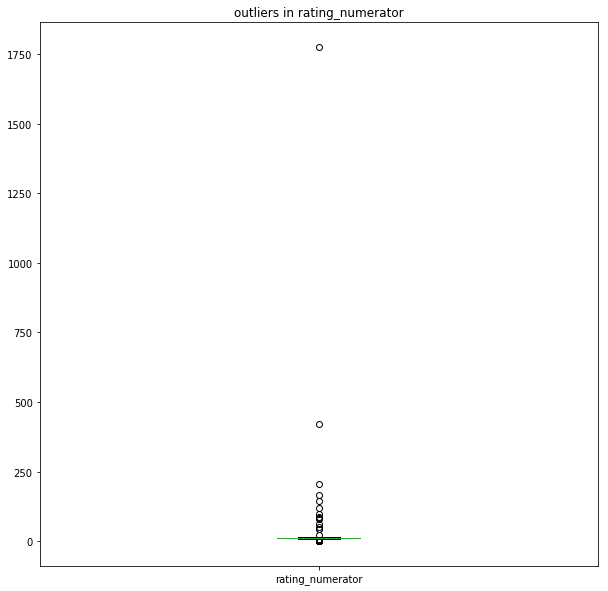

In [230]:
df1['rating_numerator'].plot(kind='box', figsize=(10,10));
plt.title('outliers in rating_numerator');

In [231]:
# getting index of outliers
# outlier_index = df[(df['rating_denominator'] < 10) | (df['rating_denominator'] > 10)].index

In [232]:
denominator_outlier_index = get_outlier_index(df1, 'rating_denominator')

In [233]:
drop(df1, denominator_outlier_index, 0)

In [234]:
#df['rating_denominator']

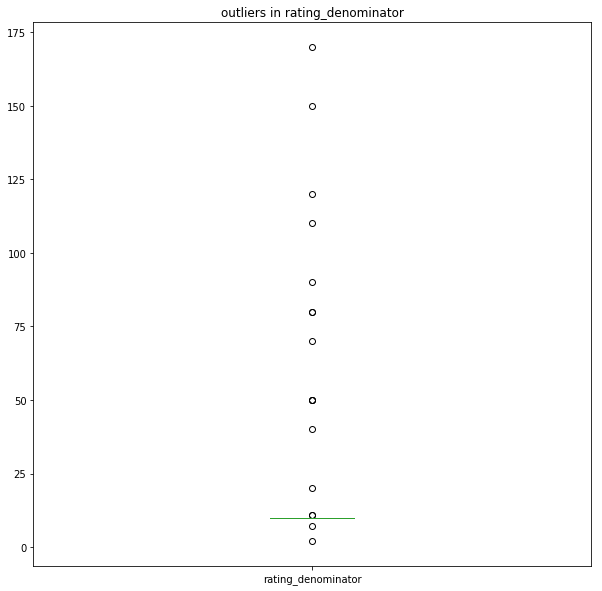

In [235]:
df['rating_denominator'].plot(kind='box', figsize=(10,10));
plt.title('outliers in rating_denominator');

### Test

In [236]:
# checking for outliers
df1[(df1['rating_denominator'] < 10) | (df1['rating_denominator'] > 10)].index.value_counts().sum()

0

### <a id = out2>checking for outliers in rating_numerator</a>

### code

In [237]:
df1[(df1['rating_numerator'] > 17)].index.value_counts().sum()

2

In [238]:
numerator_outlier_index = get_outlier_index(df1, 'rating_numerator')
numerator_outlier_index

Int64Index([ 164,  219,  507,  529,  620,  640,  675,  697,  710,  719,
            ...
            1877, 1883, 1887, 1891, 1895, 1899, 1903, 1910, 1912, 1913],
           dtype='int64', length=113)

In [239]:
df1['rating_numerator'].loc[219]

0.0

In [240]:
drop(df1,numerator_outlier_index,axis=0 )

### test

In [241]:
df1.describe()

,tweet_id,rating_numerator,rating_denominator,retweet_count,favorite_count,confidence
count,1.787000e+03,1787.000000,1787.0,1787.000000,1787.000000,1787.000000
mean,7.384549e+17,10.924331,10.0,2818.611080,9121.197538,0.482491
std,6.796859e+16,1.556103,0.0,4784.143225,12387.160468,0.334676
min,6.660209e+17,7.000000,10.0,16.000000,81.000000,0.000000
25%,6.767941e+17,10.000000,10.0,620.500000,2053.500000,0.181855
50%,7.116948e+17,11.000000,10.0,1402.000000,4229.000000,0.482452
75%,7.928288e+17,12.000000,10.0,3275.500000,11654.500000,0.788406
max,8.924206e+17,14.000000,10.0,79515.000000,132810.000000,0.999956


## <a id = ana1>Analyzing and Visualizing Data
In this section, analyze and visualize your wrangled data. You must produce at least **three (3) insights and one (1) visualization.**

### <a id = que1>Question 1:  which mobile device is the mostly used by usersers of </a>

In [242]:
# getting value count for each tweet sources which also indicates device used.
user_sources = df1['source'].value_counts()
user_sources

Twitter for iPhone    1751
Twitter Web Client      27
TweetDeck                9
Name: source, dtype: int64

In [243]:
# coverting the values in user_source into an array to know by how much is one source more that others
s = np.array(user_sources)
s

array([1751,   27,    9])

In [244]:
# estimating by how much iphone source is more than others 
iphone_by_how_much= s[0]/(s[1]+s[2])
iphone_by_how_much

48.638888888888886

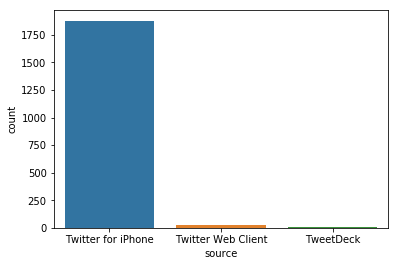

In [245]:
# constructing barchart for most used source
sb.countplot(data= df1, x = df['source']);

#### iphone is the most used device by over fourty time  more than other devices

### <a id = que2>Question 2:  which is month has the most engagement over the three years period</a>

In [246]:
# extracting months and creating month column
df1['month'] = df1['timestamp'].dt.month

In [247]:
count = df1['month'].value_counts()
count

12    365
11    302
1     214
2     158
3     153
7     132
6     112
5      87
4      84
10     65
9      58
8      57
Name: month, dtype: int64

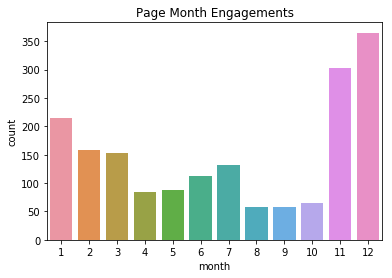

In [248]:
# constructing barchart for page engagement 
sb.countplot(data= df1, x =df1['month']);
plt.title('Page Month Engagements');

#### most engagement happens towards the end of the year with December having highest engagement.

### <a id = que3>Question 3: what is the page usage ( trend ) over the three years</a>

In [249]:
# extracting year and creating year column
df1['year'] = df1['timestamp'].dt.year

In [250]:
df1['year'].value_counts(sort=False)

2015    565
2016    887
2017    335
Name: year, dtype: int64

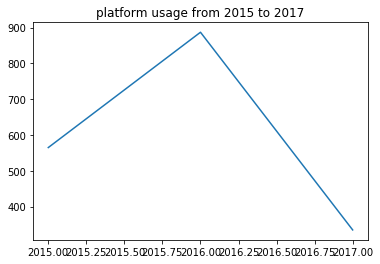

In [251]:
# plottingline graph for platform usgae acroos three years peroid 
plt.plot(df1['year'].value_counts(sort=False));
plt.title('platform usage from 2015 to 2017');

#### page engagement declined from 2016 to 2017

### <a id = ins1>Insights:
1. majority of the users are iphone users. Iphone users appears to be over forty times more than other sources or deviced used. 

2. december had most engagement across the years

3. usage of the page has been declining 

### <a id = vis1>Visualization</a>

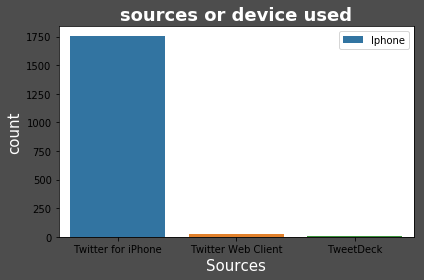

In [252]:
labels = ['Iphone','Web', 'Deck']
ax = sb.countplot(x='source', dodge=False, data=df1)
ax.set_title('sources or device used', fontsize=18, fontweight='bold', color='white')
ax.set_xlabel('Sources', fontsize=15, color='white')
ax.set_ylabel('count', fontsize=15, color='white')
ax.figure.set_facecolor('0.3')
plt.legend(labels=labels)
plt.tight_layout()
plt.show()

### <a id = res1>Refrences
- stackoverflow
- youtube